# Telco Customer Churn 

In [ ]:
# Imports 
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

from xgboost import XGBClassifier
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_PATH = Path("/fc36b1b2-187b-484d-9cbc-3f92049e381e.csv")
OUTPUT_DIR = Path("/telco_classical_ml_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Load and inspect the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumn types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
display(df["Churn"].value_counts().to_frame("count"))
display((df["Churn"].value_counts(normalize=True) * 100).round(2).to_frame("percent"))


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Column types:


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Target distribution:


,count
Churn,
No,5174
Yes,1869


,percent
Churn,
No,73.46
Yes,26.54


## 2. Data cleaning

In [3]:
df = df.copy()

# Convert target to 0/1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# Convert TotalCharges safely to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after TotalCharges conversion:")
display(df.isna().sum().sort_values(ascending=False).head(10).to_frame("missing"))

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

# ID is not a model feature
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

print("\nFeature matrix:", X.shape)
print("Target vector:", y.shape)


Missing values after TotalCharges conversion:


,missing
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


Duplicate rows: 0
Duplicate customer IDs: 0

Feature matrix: (7043, 19)
Target vector: (7043,)


## 3. Stratified train/validation/test split

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(X_train), len(X_val), len(X_test)],
    "Churn_Count": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "Churn_Rate": [y_train.mean(), y_val.mean(), y_test.mean()]
})

display(split_summary)


,Split,Rows,Churn_Count,Churn_Rate
0,Train,4930,1308,0.265314
1,Validation,1056,280,0.265152
2,Test,1057,281,0.265847


## 4. Data preprocessing

In [5]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Transformed train shape:", X_train_p.shape)
print("Transformed validation shape:", X_val_p.shape)
print("Transformed test shape:", X_test_p.shape)
print("Number of final features:", len(feature_names))

joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Transformed train shape: (4930, 45)
Transformed validation shape: (1056, 45)
Transformed test shape: (1057, 45)
Number of final features: 45


['/mnt/data/telco_classical_ml_outputs/preprocessor.joblib']

## 5. Helper functions

In [6]:
def metric_row(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

def evaluate_model(model_name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]
    return metric_row(model_name, y_eval, pred, prob), pred, prob

def plot_train_val_curve(x_values, train_scores, val_scores, xlabel, title):
    plt.figure(figsize=(7, 4.5))
    plt.plot(x_values, train_scores, marker="o", label="Train F1")
    plt.plot(x_values, val_scores, marker="o", label="Validation F1")
    plt.xlabel(xlabel)
    plt.ylabel("F1-score")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


# 6. Logistic Regression


Best C: 0.1
Best validation F1: 0.6247


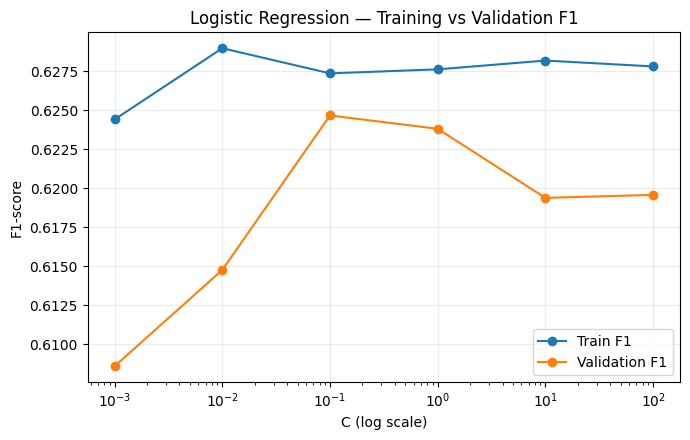

In [7]:
logreg_c_values = [0.001, 0.01, 0.1, 1, 10, 100]
logreg_train_f1 = []
logreg_val_f1 = []
logreg_models = {}

for c in logreg_c_values:
    model = LogisticRegression(
        C=c,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED
    )
    model.fit(X_train_p, y_train)

    logreg_train_f1.append(f1_score(y_train, model.predict(X_train_p)))
    logreg_val_f1.append(f1_score(y_val, model.predict(X_val_p)))
    logreg_models[c] = model

best_logreg_c = logreg_c_values[int(np.argmax(logreg_val_f1))]
logreg = logreg_models[best_logreg_c]

print("Best C:", best_logreg_c)
print("Best validation F1:", round(max(logreg_val_f1), 4))

plt.figure(figsize=(7, 4.5))
plt.plot(logreg_c_values, logreg_train_f1, marker="o", label="Train F1")
plt.plot(logreg_c_values, logreg_val_f1, marker="o", label="Validation F1")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("F1-score")
plt.title("Logistic Regression — Training vs Validation F1")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# 7. Decision Tree

Best max_depth: 3
Best validation F1: 0.6218


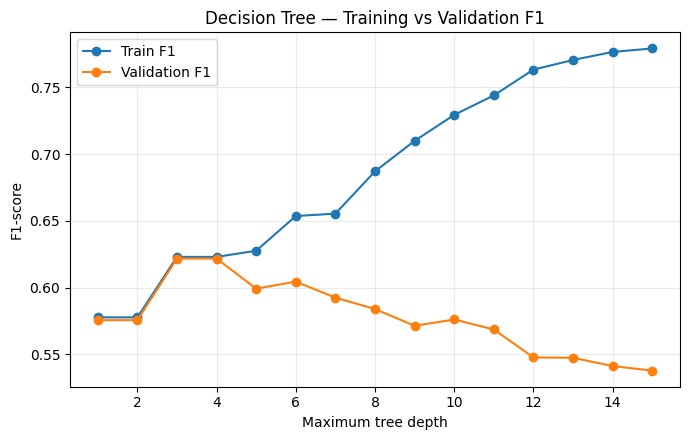

In [8]:
tree_depths = list(range(1, 16))
tree_train_f1 = []
tree_val_f1 = []
tree_models = {}

for depth in tree_depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEED
    )
    model.fit(X_train_p, y_train)

    tree_train_f1.append(f1_score(y_train, model.predict(X_train_p)))
    tree_val_f1.append(f1_score(y_val, model.predict(X_val_p)))
    tree_models[depth] = model

best_tree_depth = tree_depths[int(np.argmax(tree_val_f1))]
decision_tree = tree_models[best_tree_depth]

print("Best max_depth:", best_tree_depth)
print("Best validation F1:", round(max(tree_val_f1), 4))

plot_train_val_curve(
    tree_depths, tree_train_f1, tree_val_f1,
    "Maximum tree depth",
    "Decision Tree — Training vs Validation F1"
)


# 8. Random Forest

Best n_estimators: 50
Best validation F1: 0.6208


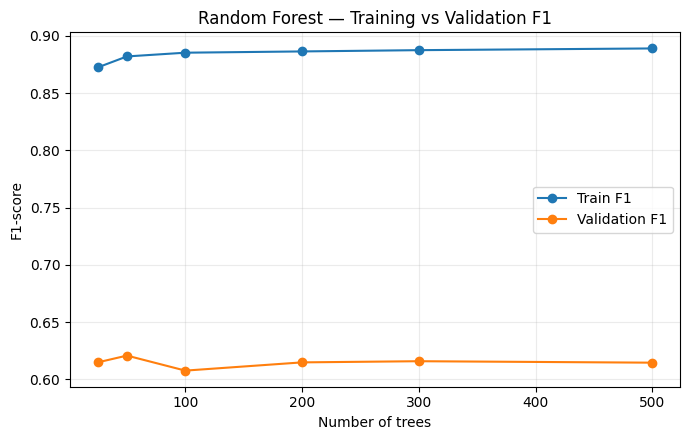

In [9]:
rf_estimators = [25, 50, 100, 200, 300, 500]
rf_train_f1 = []
rf_val_f1 = []
rf_models = {}

for n_trees in rf_estimators:
    model = RandomForestClassifier(
        n_estimators=n_trees,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train_p, y_train)

    rf_train_f1.append(f1_score(y_train, model.predict(X_train_p)))
    rf_val_f1.append(f1_score(y_val, model.predict(X_val_p)))
    rf_models[n_trees] = model

best_rf_estimators = rf_estimators[int(np.argmax(rf_val_f1))]
random_forest = rf_models[best_rf_estimators]

print("Best n_estimators:", best_rf_estimators)
print("Best validation F1:", round(max(rf_val_f1), 4))

plot_train_val_curve(
    rf_estimators, rf_train_f1, rf_val_f1,
    "Number of trees",
    "Random Forest — Training vs Validation F1"
)


# 9. XGBoost

Training negatives: 3622
Training positives: 1308
scale_pos_weight: 2.7691


Best boosting iteration: 213
Best validation score: 0.48849545084257523


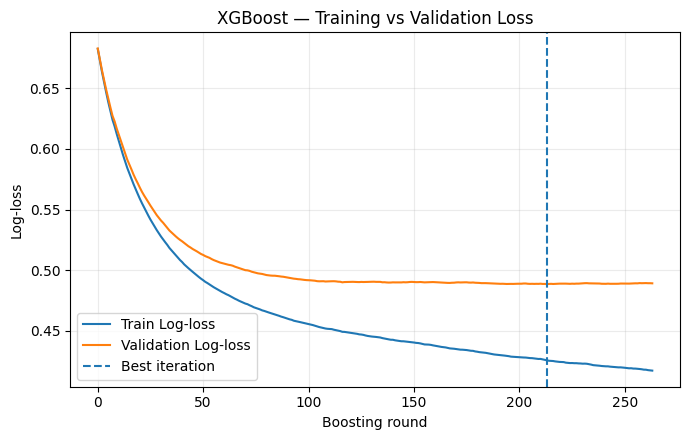

In [10]:
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count

print("Training negatives:", neg_count)
print("Training positives:", pos_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

xgboost_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=50,
    random_state=SEED,
    n_jobs=-1
)

xgboost_model.fit(
    X_train_p, y_train,
    eval_set=[(X_train_p, y_train), (X_val_p, y_val)],
    verbose=False
)

evals_result = xgboost_model.evals_result()
train_logloss = evals_result["validation_0"]["logloss"]
val_logloss = evals_result["validation_1"]["logloss"]

print("Best boosting iteration:", xgboost_model.best_iteration)
print("Best validation score:", xgboost_model.best_score)

plt.figure(figsize=(7, 4.5))
plt.plot(train_logloss, label="Train Log-loss")
plt.plot(val_logloss, label="Validation Log-loss")
if xgboost_model.best_iteration is not None:
    plt.axvline(xgboost_model.best_iteration, linestyle="--", label="Best iteration")
plt.xlabel("Boosting round")
plt.ylabel("Log-loss")
plt.title("XGBoost — Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# 10. Validation-set model comparison

In [11]:
models = {
    "Logistic Regression": logreg,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgboost_model
}

validation_rows = []

for name, model in models.items():
    row, _, _ = evaluate_model(name, model, X_val_p, y_val)
    validation_rows.append(row)

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(validation_results.round(4))
validation_results.to_csv(OUTPUT_DIR / "validation_model_comparison.csv", index=False)


,Model,Accuracy,Precision,Recall,F1,Macro_F1,Balanced_Accuracy,ROC_AUC,PR_AUC
0,XGBoost,0.7500,0.5179,0.8250,0.6364,0.7229,0.7740,0.8472,0.6485
1,Logistic Regression,0.7405,0.5067,0.8143,0.6247,0.7132,0.7641,0.8436,0.6304
2,Decision Tree,0.7500,0.5191,0.7750,0.6218,0.7175,0.7580,0.8275,0.5771
3,Random Forest,0.7860,0.5854,0.6607,0.6208,0.7359,0.7459,0.8316,0.6105


# 11. Test-set evaluation

In [12]:
test_rows = []
predictions = {}
probabilities = {}

for name, model in models.items():
    row, pred, prob = evaluate_model(name, model, X_test_p, y_test)
    test_rows.append(row)
    predictions[name] = pred
    probabilities[name] = prob

test_results = (
    pd.DataFrame(test_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(test_results.round(4))
test_results.to_csv(OUTPUT_DIR / "test_model_comparison.csv", index=False)


,Model,Accuracy,Precision,Recall,F1,Macro_F1,Balanced_Accuracy,ROC_AUC,PR_AUC
0,XGBoost,0.7578,0.5307,0.7687,0.6279,0.7242,0.7613,0.8376,0.6644
1,Logistic Regression,0.7512,0.5215,0.7758,0.6237,0.7189,0.7590,0.8439,0.6566
2,Decision Tree,0.7474,0.5174,0.7402,0.6091,0.7112,0.7451,0.8085,0.5474
3,Random Forest,0.7767,0.5768,0.6014,0.5889,0.7178,0.7208,0.8286,0.6367


## 12. Classification reports

In [13]:
all_reports = {}

for name in models:
    print("=" * 80)
    print(name)
    print("=" * 80)
    report = classification_report(
        y_test,
        predictions[name],
        target_names=["No Churn", "Churn"],
        digits=4
    )
    print(report)
    all_reports[name] = classification_report(
        y_test,
        predictions[name],
        target_names=["No Churn", "Churn"],
        output_dict=True
    )

    pd.DataFrame(all_reports[name]).T.to_csv(
        OUTPUT_DIR / f"{name.lower().replace(' ', '_')}_classification_report.csv"
    )


Logistic Regression
              precision    recall  f1-score   support

    No Churn     0.9014    0.7423    0.8141       776
       Churn     0.5215    0.7758    0.6237       281

    accuracy                         0.7512      1057
   macro avg     0.7115    0.7590    0.7189      1057
weighted avg     0.8004    0.7512    0.7635      1057

Decision Tree
              precision    recall  f1-score   support

    No Churn     0.8885    0.7500    0.8134       776
       Churn     0.5174    0.7402    0.6091       281

    accuracy                         0.7474      1057
   macro avg     0.7030    0.7451    0.7112      1057
weighted avg     0.7899    0.7474    0.7591      1057

Random Forest
              precision    recall  f1-score   support

    No Churn     0.8534    0.8402    0.8468       776
       Churn     0.5768    0.6014    0.5889       281

    accuracy                         0.7767      1057
   macro avg     0.7151    0.7208    0.7178      1057
weighted avg     0.7799   

## 13. Confusion matrices

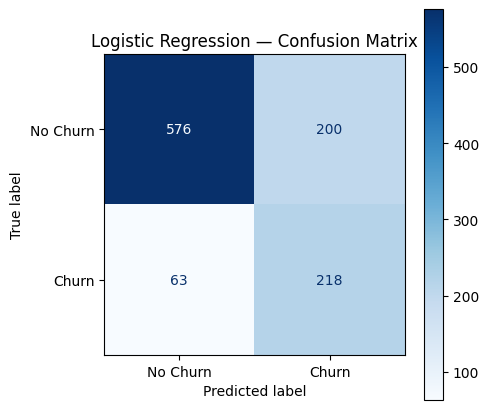

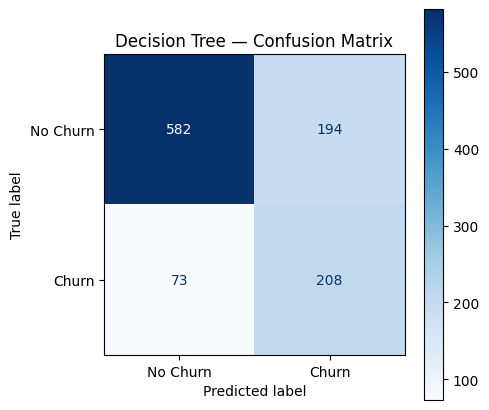

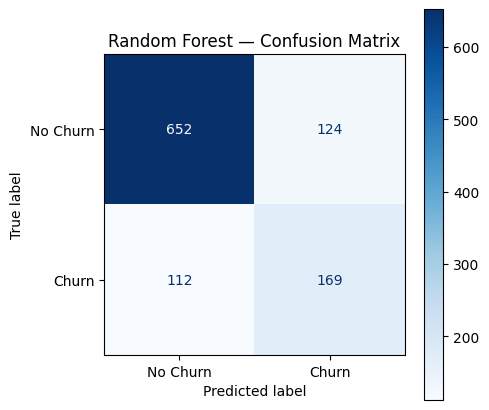

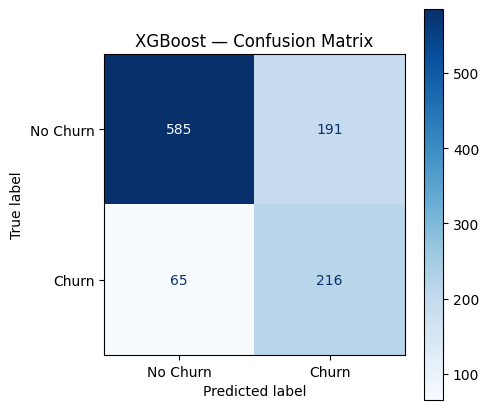

In [14]:
for name in models:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        values_format="d",
        ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()


## 14. ROC curves

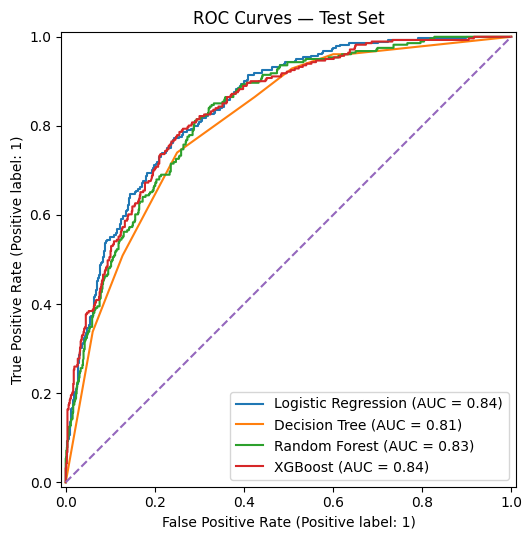

In [15]:
plt.figure(figsize=(7, 5.5))
ax = plt.gca()

for name in models:
    RocCurveDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=ax
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves — Test Set")
plt.tight_layout()
plt.show()


## 15. Precision–Recall curves

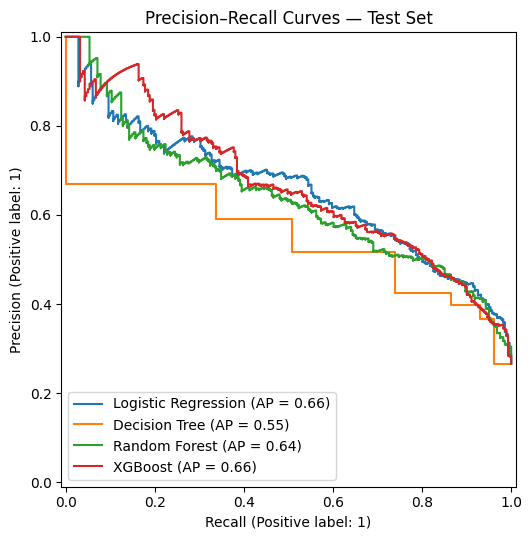

In [16]:
plt.figure(figsize=(7, 5.5))
ax = plt.gca()

for name in models:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities[name],
        name=name,
        ax=ax
    )

plt.title("Precision–Recall Curves — Test Set")
plt.tight_layout()
plt.show()


# 16. Generalization-gap analysis

In [17]:
gap_rows = []

for name, model in models.items():
    train_pred = model.predict(X_train_p)
    val_pred = model.predict(X_val_p)

    train_f1 = f1_score(y_train, train_pred)
    val_f1 = f1_score(y_val, val_pred)

    gap_rows.append({
        "Model": name,
        "Train_F1": train_f1,
        "Validation_F1": val_f1,
        "F1_Generalization_Gap": train_f1 - val_f1
    })

generalization_gap = pd.DataFrame(gap_rows).sort_values(
    "F1_Generalization_Gap",
    ascending=False
)

display(generalization_gap.round(4))
generalization_gap.to_csv(OUTPUT_DIR / "generalization_gap.csv", index=False)


,Model,Train_F1,Validation_F1,F1_Generalization_Gap
2,Random Forest,0.8821,0.6208,0.2613
3,XGBoost,0.6820,0.6364,0.0456
0,Logistic Regression,0.6274,0.6247,0.0027
1,Decision Tree,0.6230,0.6218,0.0012


# 17. Feature importance / model interpretation

,Feature,Coefficient,Importance
1,num__tenure,-1.001148,1.001148
36,cat__Contract_Month-to-month,0.679182,0.679182
38,cat__Contract_Two year,-0.612169,0.612169
3,num__TotalCharges,0.356001,0.356001
16,cat__InternetService_Fiber optic,0.336946,0.336946
43,cat__PaymentMethod_Electronic check,0.277087,0.277087
15,cat__InternetService_DSL,-0.258778,0.258778
18,cat__OnlineSecurity_No,0.257041,0.257041
27,cat__TechSupport_No,0.226188,0.226188
40,cat__PaperlessBilling_Yes,0.188541,0.188541


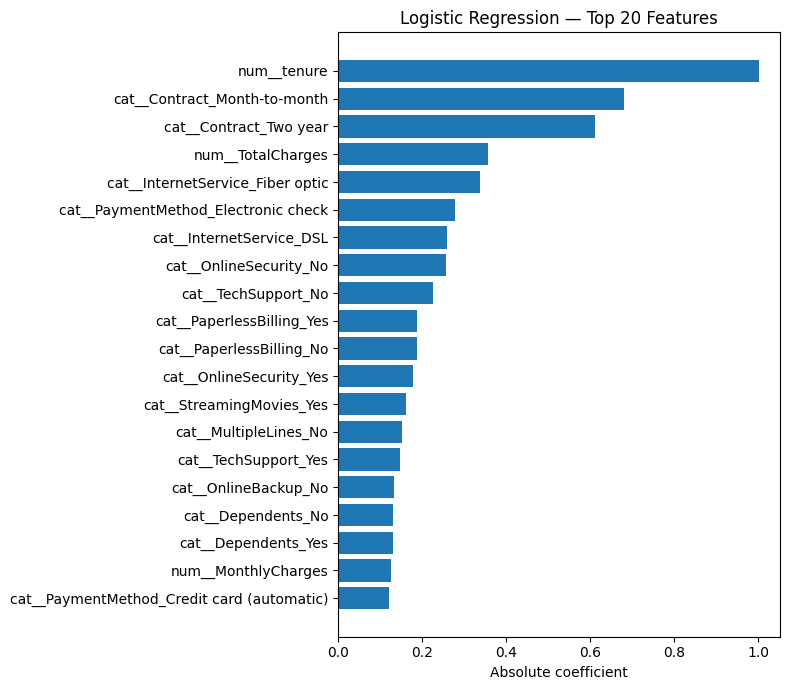

In [18]:
# Logistic Regression coefficients
logreg_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logreg.coef_[0],
    "Importance": np.abs(logreg.coef_[0])
}).sort_values("Importance", ascending=False)

display(logreg_importance.head(20))
logreg_importance.to_csv(OUTPUT_DIR / "logistic_regression_coefficients.csv", index=False)

top = logreg_importance.head(20).sort_values("Importance")
plt.figure(figsize=(8, 7))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Absolute coefficient")
plt.title("Logistic Regression — Top 20 Features")
plt.tight_layout()
plt.show()


,Feature,Importance
36,cat__Contract_Month-to-month,0.701542
1,num__tenure,0.122279
16,cat__InternetService_Fiber optic,0.116833
2,num__MonthlyCharges,0.041190
18,cat__OnlineSecurity_No,0.018156
5,cat__gender_Male,0.000000
6,cat__Partner_No,0.000000
7,cat__Partner_Yes,0.000000
8,cat__Dependents_No,0.000000
9,cat__Dependents_Yes,0.000000


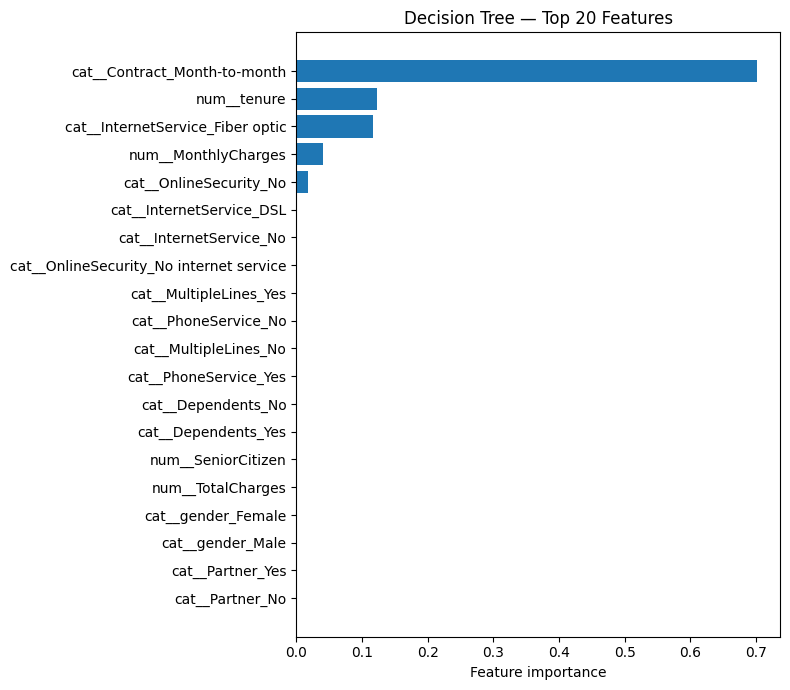

,Feature,Importance
1,num__tenure,0.127787
3,num__TotalCharges,0.121540
2,num__MonthlyCharges,0.101421
36,cat__Contract_Month-to-month,0.085894
18,cat__OnlineSecurity_No,0.056244
16,cat__InternetService_Fiber optic,0.043240
27,cat__TechSupport_No,0.036893
38,cat__Contract_Two year,0.035536
43,cat__PaymentMethod_Electronic check,0.032792
21,cat__OnlineBackup_No,0.016240


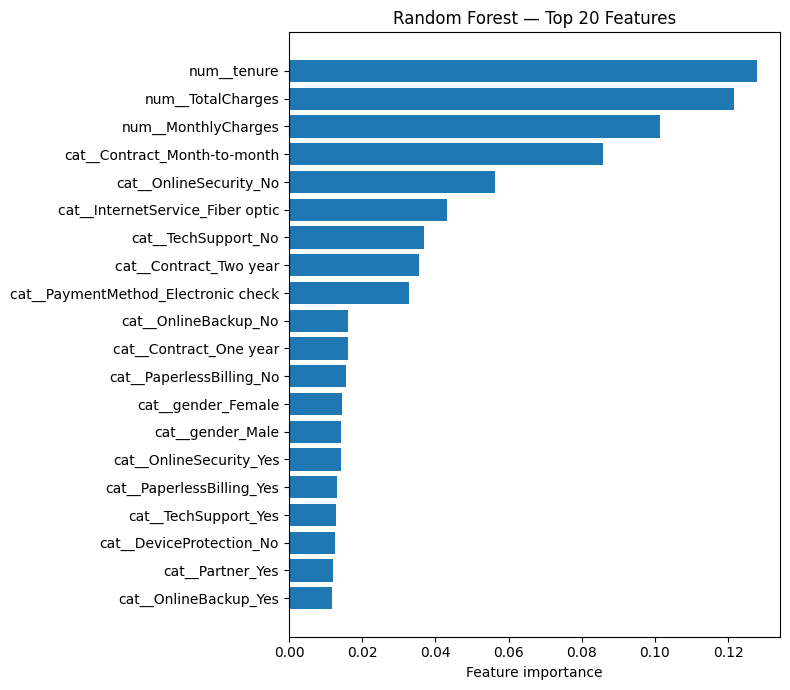

,Feature,Importance
36,cat__Contract_Month-to-month,0.388783
16,cat__InternetService_Fiber optic,0.081133
18,cat__OnlineSecurity_No,0.062943
27,cat__TechSupport_No,0.050052
38,cat__Contract_Two year,0.034264
19,cat__OnlineSecurity_No internet service,0.022114
35,cat__StreamingMovies_Yes,0.021196
15,cat__InternetService_DSL,0.020733
37,cat__Contract_One year,0.020083
43,cat__PaymentMethod_Electronic check,0.019636


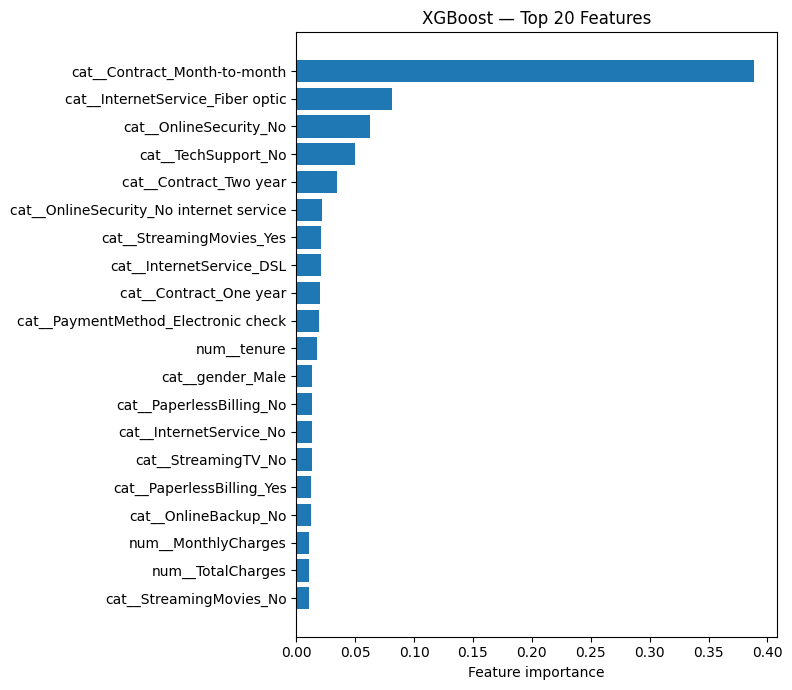

In [19]:
tree_based_models = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgboost_model
}

for name, model in tree_based_models.items():
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))
    importance_df.to_csv(
        OUTPUT_DIR / f"{name.lower().replace(' ', '_')}_feature_importance.csv",
        index=False
    )

    top = importance_df.head(20).sort_values("Importance")
    plt.figure(figsize=(8, 7))
    plt.barh(top["Feature"], top["Importance"])
    plt.xlabel("Feature importance")
    plt.title(f"{name} — Top 20 Features")
    plt.tight_layout()
    plt.show()


# 18. Save predictions and trained models

In [20]:
prediction_df = pd.DataFrame({
    "True_Label": y_test.reset_index(drop=True)
})

for name in models:
    safe_name = name.lower().replace(" ", "_")
    prediction_df[f"{safe_name}_prediction"] = predictions[name]
    prediction_df[f"{safe_name}_probability"] = probabilities[name]

display(prediction_df.head())
prediction_df.to_csv(OUTPUT_DIR / "test_predictions_all_models.csv", index=False)

for name, model in models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, OUTPUT_DIR / f"{safe_name}.joblib")

print("Saved all models and outputs to:", OUTPUT_DIR)


,True_Label,logistic_regression_prediction,logistic_regression_probability,decision_tree_prediction,decision_tree_probability,random_forest_prediction,random_forest_probability,xgboost_prediction,xgboost_probability
0,1,1,0.682042,0,0.407201,0,0.477512,1,0.594297
1,0,0,0.249593,0,0.245432,0,0.196618,0,0.301072
2,0,0,0.093487,0,0.245432,0,0.226466,0,0.093248
3,0,0,0.357614,1,0.657247,0,0.359583,0,0.348853
4,0,0,0.027107,0,0.245432,0,0.077130,0,0.058281


Saved all models and outputs to: /mnt/data/telco_classical_ml_outputs
